In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


dataset = pd.read_csv('../data/wine_data.csv')
dataset.head()

,inputs Alcohol,MalicAcid,Ash,AlcalinityOfAsh,Magnesium,TotalPhenols,flavanoids,NonflavanoidsPhenols,Proanthocyanins,ColorIntensity,Hue,OD280/OD315,Proline,Cultivar
0,12.08,1.33,2.30,23.6,70,2.20,1.59,0.42,1.38,1.74,1.07,3.21,625,1
1,12.08,1.13,2.51,24.0,78,2.00,1.58,0.40,1.40,2.20,1.31,2.72,630,1
2,12.37,1.17,1.92,19.6,78,2.11,2.00,0.27,1.04,4.68,1.12,3.48,510,1
3,13.11,1.01,1.70,15.0,78,2.98,3.18,0.26,2.28,5.30,1.12,3.18,502,1
4,12.04,4.30,2.38,22.0,80,2.10,1.75,0.42,1.35,2.60,0.79,2.57,580,1


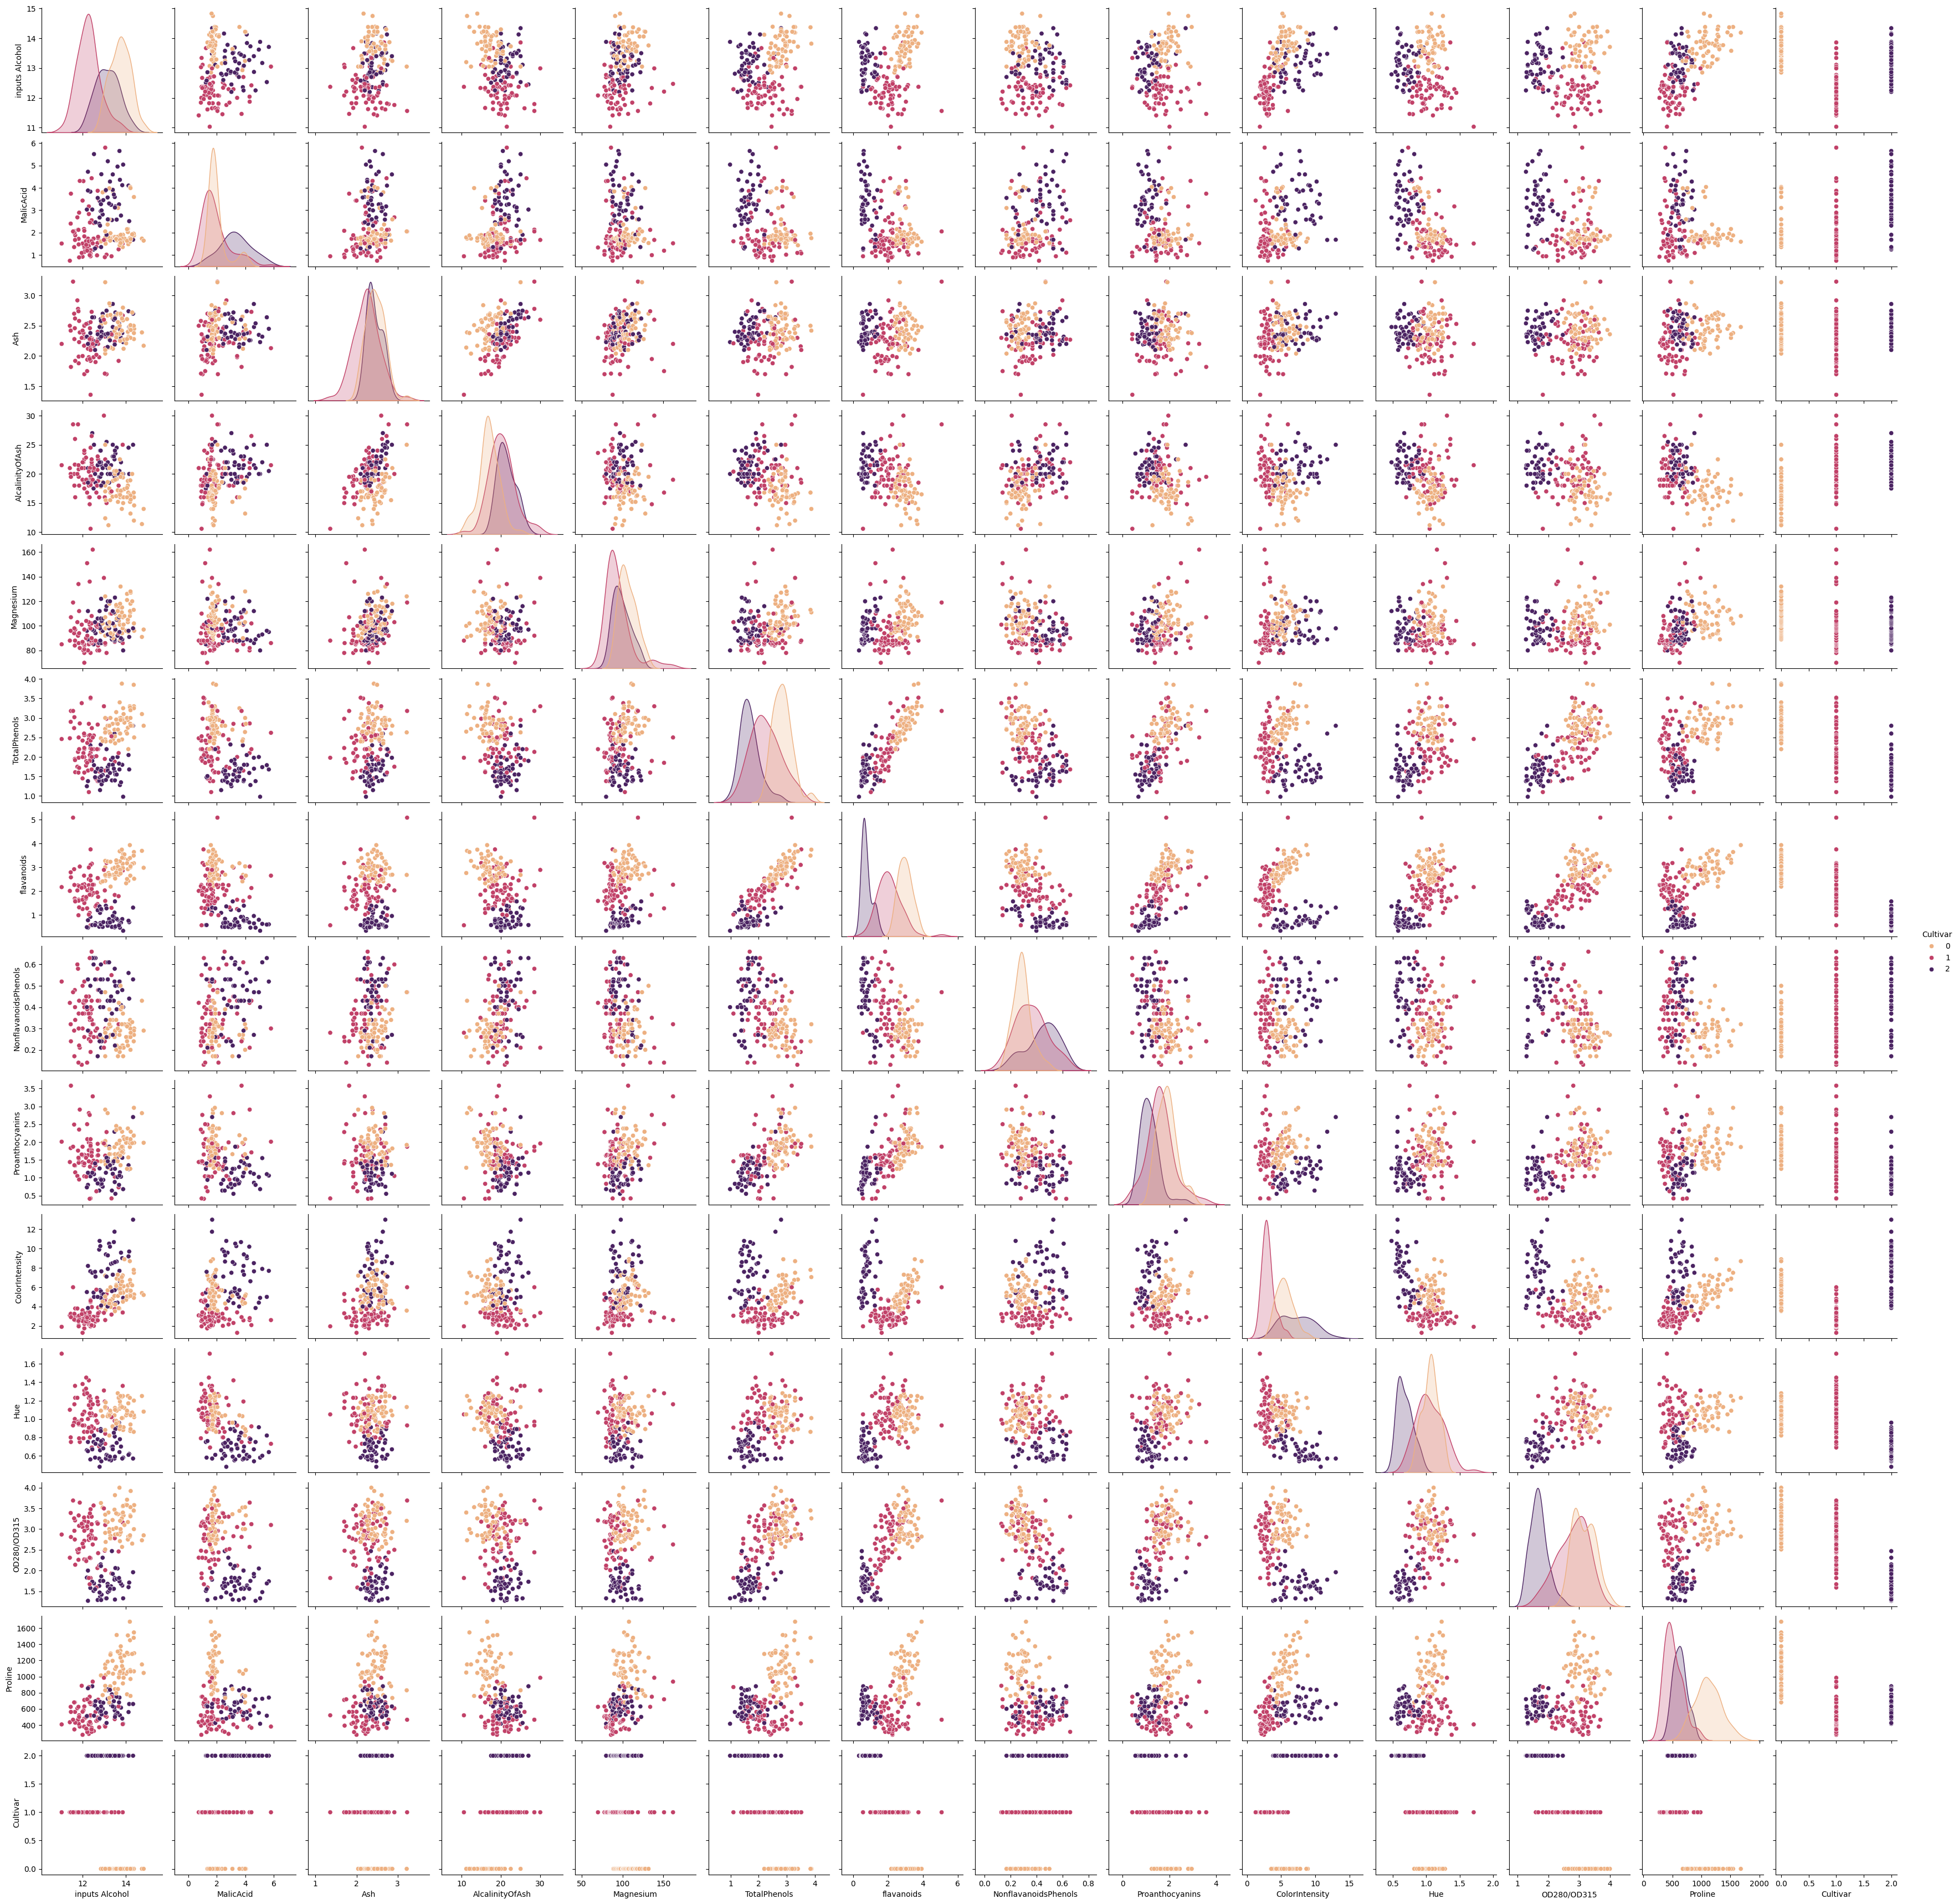

In [3]:
sns.pairplot(dataset, hue="Cultivar", vars=dataset[:11], palette="flare")

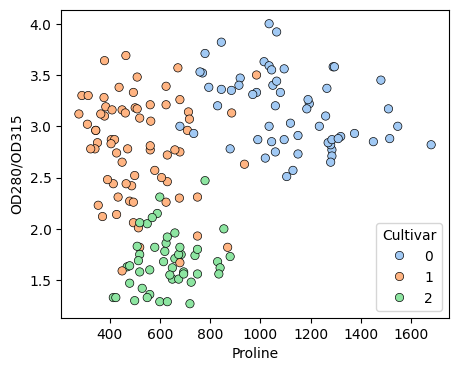

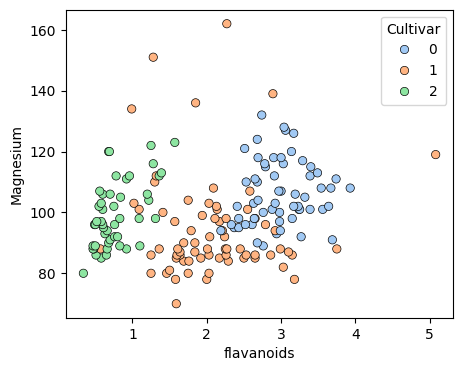

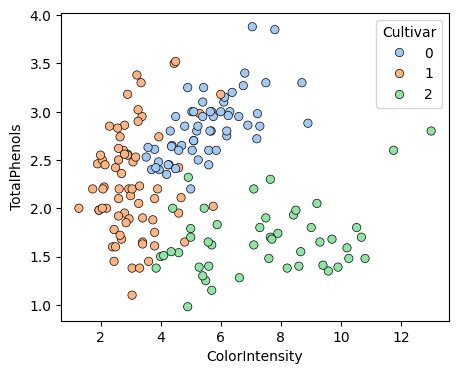

In [19]:
plt.figure(figsize=(5,4))

sns.scatterplot(
    data=dataset,
    x='Proline', 
    y='OD280/OD315', 
    hue='Cultivar',
    palette='pastel',
    edgecolor='black'
)
plt.show()
plt.figure(figsize=(5,4))
sns.scatterplot(
    data=dataset,
    x='flavanoids', 
    y='Magnesium', 
    hue='Cultivar',
    palette='pastel',
    edgecolor='black'
)
plt.show()
plt.figure(figsize=(5,4))
sns.scatterplot(
    data=dataset,
    x='ColorIntensity', 
    y='TotalPhenols', 
    hue='Cultivar',
    palette='pastel',
    edgecolor='black'
)
plt.show()


In [14]:
# normaal gezien hebben we de informatie niet op voorhand en hebben juist de unsupervised clusterer om die te maken
df = dataset.drop("Cultivar", axis=1)

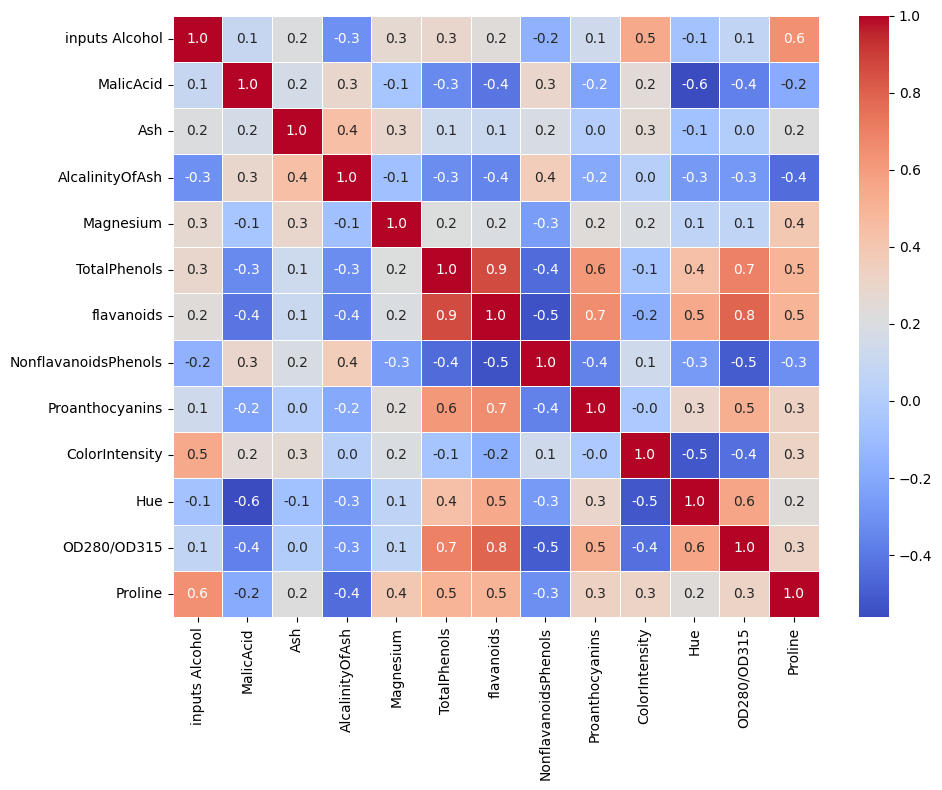

In [8]:
dfc = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
        dfc,
        annot=True,        
        fmt=".1f",         
        cmap="coolwarm",   
        linewidths=0.5
    )

plt.tight_layout()
plt.show()

In [ ]:
# TotalPhenols and flavanoids are very much correlated, also flavanoids and OD.. and flavanoids and Proanthocyanins

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_df = scaler.fit_transform(df)

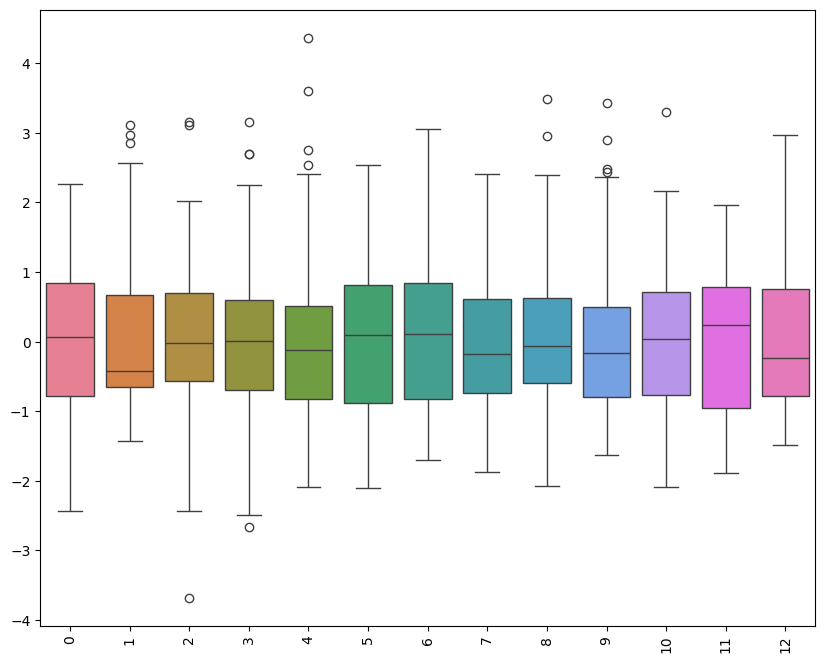

In [23]:
plt.figure(figsize=(10, 8))
sns.boxplot(data=scaled_df)
plt.xticks(rotation=90)
plt.show()

In [16]:
from sklearn.cluster import KMeans

In [27]:
k_model = KMeans(n_clusters=2, n_init='auto') 

In [28]:
cluster_labels = k_model.fit_predict(scaled_df)
cluster_labels

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1], dtype=int32)

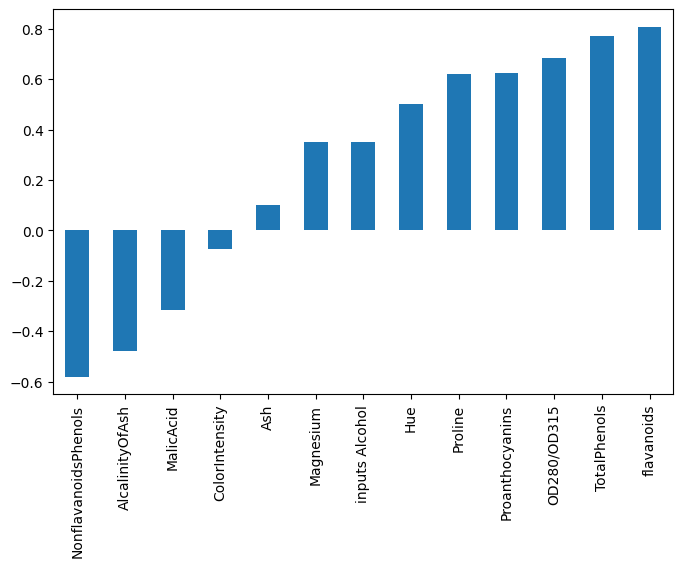

In [30]:
df['Cluster'] = cluster_labels
plt.figure(figsize=(8, 5))
df.corr()['Cluster'].iloc[:-1].sort_values().plot(kind='bar')
plt.show()

In [17]:
import numpy as np

# Kiezen best K
npoints = 7
ssd = []

clusters_df = np.zeros((scaled_df.shape[0], npoints-2))

for k in range(2, npoints):    
    model = KMeans(n_clusters=k, n_init=50)    
    model.fit(scaled_df)    
    ssd.append(model.inertia_) # .inertia_ == SSD van de samples tot hun centroïde
    cluster_labels = model.fit_predict(scaled_df)
    clusters_df[:, k-2] = cluster_labels

# Attach the cluster labels to the original matrix
for i in range(2, npoints):
    df[f'Cluster_{i}'] = clusters_df[:, i-2]

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   inputs Alcohol        178 non-null    float64
 1   MalicAcid             178 non-null    float64
 2   Ash                   178 non-null    float64
 3   AlcalinityOfAsh       178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   TotalPhenols          178 non-null    float64
 6   flavanoids            178 non-null    float64
 7   NonflavanoidsPhenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   ColorIntensity        178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280/OD315           178 non-null    float64
 12  Proline               178 non-null    int64  
 13  Cluster_2             178 non-null    float64
 14  Cluster_3             178 non-null    float64
 15  Cluster_4             1

In [19]:
import plotly.express as px

fig = px.parallel_coordinates(df, color='Cluster_3', dimensions=['Cluster_3', "Magnesium", "Proline", "OD280/OD315"])
fig.show()

Text(0, 0.5, 'Sum of Squared Distances')

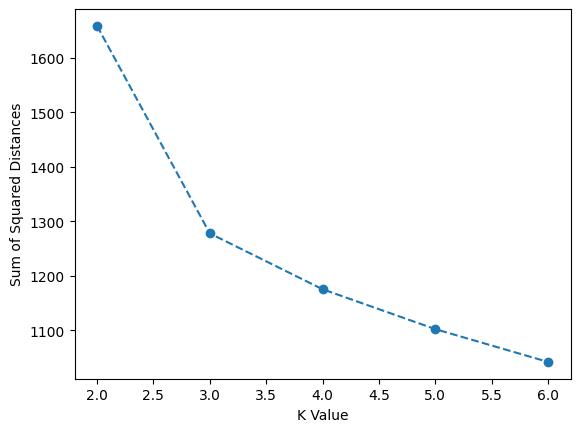

In [20]:
plt.plot(range(2,npoints),ssd,'o--')
plt.xlabel("K Value")
plt.ylabel("Sum of Squared Distances")

In [ ]:
# 3 clusters is duidelijk de beste waarde voor K
# hoeveel van elk klass zit in predities met 3 clusters?
df["Cluster_3"].value_counts()

Cluster_3
2.0    65
0.0    62
1.0    51
Name: count, dtype: int64

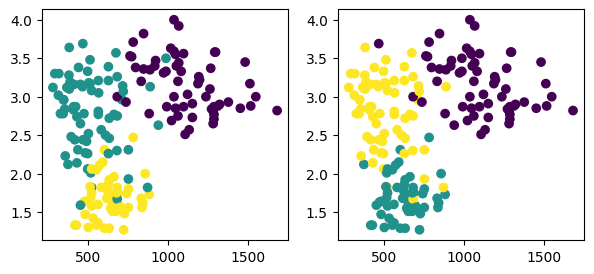

In [29]:
# visueel vergelijken met het origineel:
fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].scatter(
    data=dataset,
    x='Proline', 
    y='OD280/OD315', 
    c='Cultivar',
)

ax[1].scatter(
    data=df,
    x='Proline', 
    y='OD280/OD315', 
    c="Cluster_3",
)
plt.show()